# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

In [4]:
# your code here
from scipy.stats import uniform
single_num = uniform.rvs(loc=10, scale=50)
single_num

np.float64(38.51959001490507)

**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

In [5]:
# your code here
def generate_uniform_numbers(bottom, ceiling, count):
    """
    Generates an array of uniformly distributed random numbers.
    loc = bottom
    scale = ceiling - bottom (the range width)
    """
    width = ceiling - bottom
    return uniform.rvs(loc=bottom, scale=width, size=count)

In [7]:
# your code here
set_1 = generate_uniform_numbers(bottom=10, ceiling=15, count=100)
set_2 = generate_uniform_numbers(bottom=10, ceiling=60, count=1000)

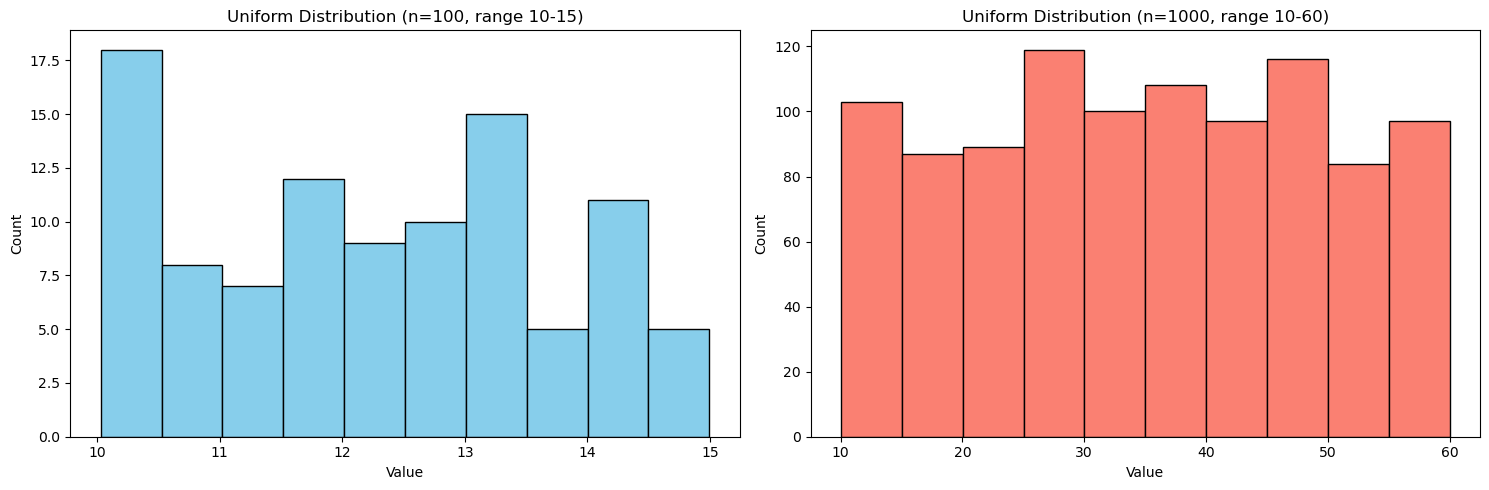

In [8]:
# your code here
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.hist(set_1, bins=10, color='skyblue', edgecolor='black')
ax1.set_title('Uniform Distribution (n=100, range 10-15)')
ax1.set_xlabel('Value')
ax1.set_ylabel('Count')

ax2.hist(set_2, bins=10, color='salmon', edgecolor='black')
ax2.set_title('Uniform Distribution (n=1000, range 10-60)')
ax2.set_xlabel('Value')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

How are the two distributions different?

The two distributions differ in three main ways: Range, Sample Size (Stability), and Expected Value.
1. The Range (Spread)
Set 1 is very narrow. All generated numbers fall between 10 and 15 (a spread of only 5 units).
Set 2 is much wider. The numbers are spread out between 10 and 60 (a spread of 50 units).
Visual impact: If you looked at the X-axis of your plots, you noticed Set 2 covers a much larger "territory" than Set 1.
2. Sample Size and "Flatness" (Noise)
Set 1 (100 samples): With only 100 numbers divided into 10 bins, you likely noticed the histogram bars were uneven (some tall, some short). This is called sampling noise. In a small sample, randomness doesn't "even out" perfectly.
Set 2 (1,000 samples): Because there are 10 times more data points, the distribution looks much "flatter." According to the Law of Large Numbers, as you increase the count, the histogram will look more and more like a perfect rectangle (the theoretical shape of a uniform distribution).
3. Expected Value (The Mean)
The center point of these distributions is different:
Set 1 Mean: Should be approximately 12.5 (the midpoint of 10 and 15).
Set 2 Mean: Should be approximately 35 (the midpoint of 10 and 60).
4. Probability Density (Theoretical Difference)
If you were to look at the probability (instead of the count), Set 1 is "denser."
In Set 1, you have a 100% chance of landing within a 5-unit window.
In Set 2, that 100% chance is stretched across a 50-unit window.
Therefore, any specific sub-range in Set 1 is much more likely to contain a number than the same sized sub-range in Set 2.

In [6]:
# your answer below

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [13]:
from scipy.stats import norm 

In [14]:
# your code here
def generate_normal_numbers(mean, std_dev, count):
    return norm.rvs(loc=mean, scale=std_dev, size=count)

In [15]:
# your code here
set_a = generate_normal_numbers(mean=10, std_dev=1, count=1000)
set_b = generate_normal_numbers(mean=10, std_dev=50, count=1000)

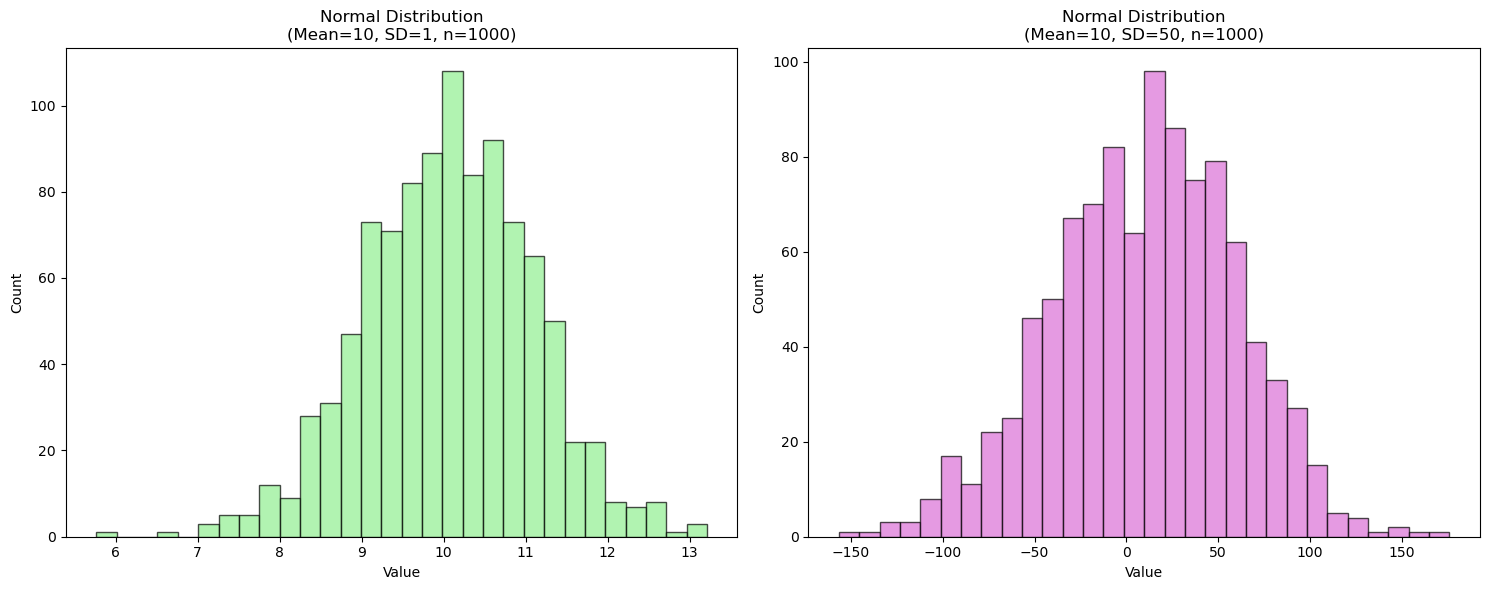

In [19]:
# your code here
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.hist(set_a, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax1.set_title('Normal Distribution\n(Mean=10, SD=1, n=1000)')
ax1.set_xlabel('Value')
ax1.set_ylabel('Count')

ax2.hist(set_b, bins=30, color='orchid', edgecolor='black', alpha=0.7)
ax2.set_title('Normal Distribution\n(Mean=10, SD=50, n=1000)')
ax2.set_xlabel('Value')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [20]:
# your code here


How are the two distributions different?

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [21]:
# your code here
real_data = pd.read_csv('vehicles.csv')

In [22]:
real_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35952 entries, 0 to 35951
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Make                     35952 non-null  object 
 1   Model                    35952 non-null  object 
 2   Year                     35952 non-null  int64  
 3   Engine Displacement      35952 non-null  float64
 4   Cylinders                35952 non-null  float64
 5   Transmission             35952 non-null  object 
 6   Drivetrain               35952 non-null  object 
 7   Vehicle Class            35952 non-null  object 
 8   Fuel Type                35952 non-null  object 
 9   Fuel Barrels/Year        35952 non-null  float64
 10  City MPG                 35952 non-null  int64  
 11  Highway MPG              35952 non-null  int64  
 12  Combined MPG             35952 non-null  int64  
 13  CO2 Emission Grams/Mile  35952 non-null  float64
 14  Fuel Cost/Year        

First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

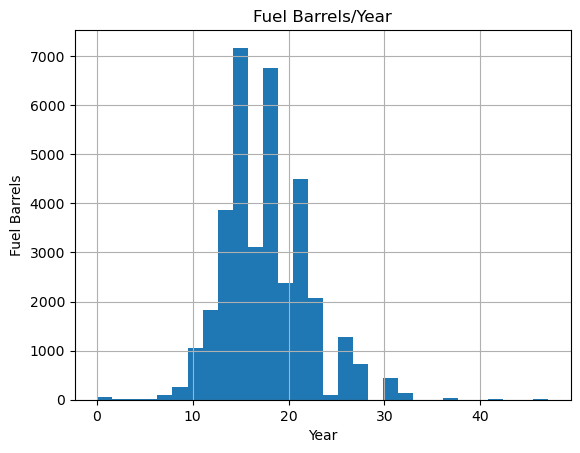

In [ ]:
# your code here
rd = real_data['Fuel Barrels/Year']
rd.hist(bins=30)
plt.title('Fuel Barrels/Year')
plt.xlabel('Year')
plt.ylabel('Fuel Barrels')
plt.show()

In [ ]:
# your code here

2. CO2 Emission Grams/Mile 

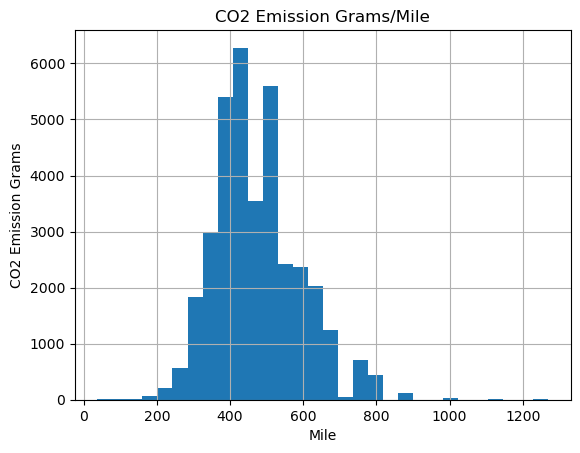

In [25]:
# your code here
rd = real_data['CO2 Emission Grams/Mile']
rd.hist(bins=30)
plt.title('CO2 Emission Grams/Mile')
plt.xlabel('Mile')
plt.ylabel('CO2 Emission Grams')
plt.show()

In [ ]:
# your code here

3. Combined MPG

In [ ]:
# your code here

In [ ]:
# your code here

In [ ]:
# your code here

Which one(s) of the variables are nearly normally distributed? How do you know?

In [ ]:
# your code here

In [ ]:
# your code here

In [ ]:
# your code here

In [ ]:
# your code here

None of them are normally ditributed. 

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

In [ ]:
# your code here

How are the two distributions different?

The mean changes, so the distribution changes as well. 

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

In [25]:
# your code here

In [ ]:
# your answer here
# Hint: This is same as saying P(x<15)

What is the probability that the customer will spend more than 15 minutes

In [ ]:
# your code here